# Previsão de Preços de Combustíveis — ANP
### Modelagem preditiva por estado e produto (GLP, Gasolina, Etanol, Diesel)

Projeto de portfólio — pipeline completo de ingestão, EDA, engenharia de features,
modelagem (XGBoost / LightGBM) e avaliação crítica dos resultados.

**Fonte de dados:** ANP (preços de combustíveis) enriquecida com indicadores
macroeconômicos (dólar, Brent, IPCA, SELIC, PIB mensal).


## 1. Contexto e objetivo

O objetivo deste projeto é prever o preço médio semanal de venda de combustíveis
(Gasolina, Etanol, Diesel, GLP) por estado, a partir de:

- Histórico de preços (lags e médias/desvios móveis)
- Indicadores macroeconômicos (dólar, Brent, IPCA, SELIC, PIB)

O projeto segue um fluxo completo: EDA → testes de hipótese → engenharia de
features → definição de baseline → modelagem → diagnóstico crítico dos
resultados.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.tools_optimize import TratamentoIniciaisDF, prepara_X_y
import os

from xgboost import XGBRegressor
import json
import pandas as pd

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')

# Carregue aqui o dataframe já tratado (saída da classe TratamentoIniciaisDF)
path = rf"{os.getcwd()}\data\dados_anp_modelado.parquet"

df = pd.read_parquet(path.replace("\\src",''))
tratamento = TratamentoIniciaisDF(path.replace("\\src",''))
df_train, df_val, df_test = tratamento.apply_filters_date()

COLUNAS_REMOVER_BASE = [
    "price_sale_median",
    "price_sale_std",
    "n_postos",
    "baixa_amostra",
    "estado_AP",
    "estado_DF",
    "price_sale_median_rolling_mean_2",
    "rolling_std_2",
]


c:\Users\ferna\anaconda3\envs\main\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['Estado - Sigla', 'Produto']


## 2. Análise Exploratória (resumo)

Principais achados da EDA (detalhamento completo no notebook de EDA):

- **Distribuição de preços**: assimétrica à direita em todos os produtos
  (skewness entre 0.51 e 1.15), confirmada por teste de normalidade
  (Kolmogorov–Smirnov, p ≈ 0.0000 em todos os produtos).
- **Diferença entre estados**: confirmada por Kruskal-Wallis + post-hoc de Dunn
  — SP se destaca como outlier de preço mais baixo; padrões de cluster regional
  identificados (ex: Norte/Centro-Oeste com preços similares).
- **Correlação com exógenas**: Spearman (não-paramétrico, dado o não cumprimento
  de normalidade) — dólar e PIB mensal com correlação forte (ρ ≈ 0.6–0.7) em
  todos os produtos.


In [3]:

from scipy import stats

for produto in ['GASOLINA', 'ETANOL', 'DIESEL', 'GLP']:
    dados = df[df['Produto'] == produto]['price_sale_median'].dropna().sample(5000, random_state=42)
    stat, p = stats.kstest(dados, 'norm', args=(dados.mean(), dados.std()))
    print(f"{produto:<12} KS stat={stat:.4f}  p={p:.4f}  skew={dados.skew():.3f}")


GASOLINA     KS stat=0.1281  p=0.0000  skew=0.581
ETANOL       KS stat=0.1087  p=0.0000  skew=0.530
DIESEL       KS stat=0.1557  p=0.0000  skew=0.768
GLP          KS stat=0.1443  p=0.0000  skew=0.537


## 3. Quebras de regime identificadas — decisões metodológicas

Duas mudanças estruturais de mercado foram identificadas ao longo da análise,
com impacto direto nas decisões de modelagem:

### 3.1 — Mudança de política de preços da Petrobras (2016)
Correlação de Spearman entre `Close_BZ=F` (Brent) e o preço nacional:

| Período       | Gasolina | Etanol | Diesel | GLP    |
|---------------|----------|--------|--------|--------|
| Antes de 2015 | -0.058   | +0.075 | -0.230 | -0.063 |
| 2016+         | +0.718   | +0.635 | +0.780 | +0.705 |

**Decisão:** treino iniciado em 2016-01, descartando o período de preços
administrados (pré-PPI), que não reflete o regime de mercado atual.

### 3.2 — Salto de patamar entre 2024 e 2025-2026
O preço médio de todos os produtos aumentou de forma real e expressiva entre
o fim do período de treino e o período de teste (ex.: GLP de ~R$84 para
~R$115). O Brent, em particular, saiu de uma faixa quase estática (~R$65,
desvio padrão 0.70) para uma faixa ampla e volátil (R$60–114, desvio padrão
17.3) no período de teste — **fora do range visto durante o treino**.

**Implicação:** essa quebra não pode ser corrigida por corte de dados (é
justamente o período que se quer prever), e se mostrou a principal causa de
degradação de performance dos modelos baseados em árvore, discutida na
seção 6.


In [4]:
# Comparação Brent: fim do treino vs. teste
print("Brent — fim do treino (últimas 52 semanas):")
print(df_train['Close_BZ=F'].tail(52).describe())

print("\nBrent — período de teste:")
print(df_test['Close_BZ=F'].describe())


Brent — fim do treino (últimas 52 semanas):
count   52.0000
mean    76.6877
std      5.7202
min     64.2100
25%     72.7200
50%     75.8550
75%     81.4800
max     88.4000
Name: Close_BZ=F, dtype: float64

Brent — período de teste:
count   5,184.0000
mean       78.7254
std        17.3300
min        60.5600
25%        64.7175
50%        69.0900
75%        95.1050
max       114.4400
Name: Close_BZ=F, dtype: float64


## 4. Engenharia de features

- **Lags** definidos por PACF (série diferenciada, estacionária confirmada por
  ADF): `lag_1, lag_2, lag_3, lag_4, lag_8, lag_27` — combinando ciclos de
  curto prazo (semanal), mensal e semestral.
- **Rolling mean / std** em janelas de 4, 8 e 12 semanas — mantidas como
  candidatas múltiplas (não filtradas a priori), com a decisão final deixada
  para o `feature_importance` do modelo treinado.
- **Exógenas**: dólar, Brent, IPCA, SELIC, PIB mensal.
- **Target**: variação semanal (`price_sale_median - price_sale_median_lag_1`),
  não o nível absoluto — decisão tomada após diagnóstico de que o modelo,
  ao prever o nível absoluto, ignorava quase totalmente as exógenas em favor
  de features de curtíssimo prazo.


## 5. Baseline — referência mínima de qualidade

Baseline ingênuo: `preço previsto da próxima semana = preço da semana atual`
(`lag_1`). Qualquer modelo precisa superar este piso para agregar valor real.

| Produto  | MAE baseline (teste) |
|----------|----------------------|
| Gasolina | 0.0597 |
| Etanol   | 0.0552 |
| Diesel   | 0.0815 |
| GLP      | 1.0851 |


## 6. Modelagem — XGBoost e LightGBM

Pipeline por produto: `TimeSeriesSplit` (8 folds) → tuning bayesiano (Optuna,
50 trials) → treino no bloco de treino completo → avaliação em validação e
teste, sempre comparando contra o baseline no mesmo recorte.

### Resultado consolidado — XGBoost

| Produto  | Melhora Validação | Melhora Teste |
|----------|--------------------|---------------|
| GLP      | -4.3%  | -3.1%  |
| Gasolina | -16.4% | -22.1% |
| Etanol   | -13.6% | -12.2% |
| Diesel   | -16.1% | -30.7% |

### Resultado consolidado — LightGBM

| Produto  | Melhora Validação | Melhora Teste |
|----------|--------------------|---------------|
| GLP      | -5.5%  | -4.5%  |
| Gasolina | -8.2%  | -19.0% |
| Etanol   | -11.5% | -9.2%  |
| Diesel   | -18.2% | -37.9% |

**Nenhum dos dois algoritmos supera o baseline no teste final, em nenhum dos
quatro produtos.** A convergência de dois algoritmos independentes para o
mesmo padrão é a evidência central da conclusão na seção 7.


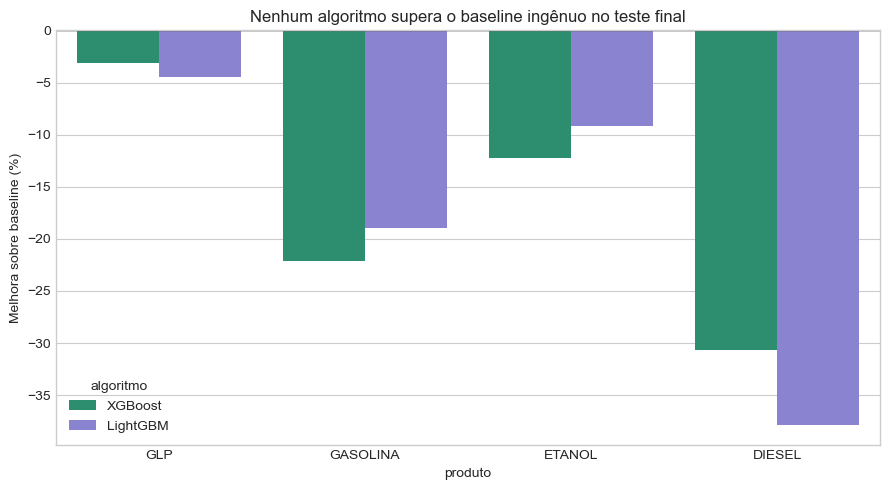

In [5]:
# Célula para consolidar e plotar a comparação XGBoost vs LightGBM vs Baseline
resultados_comparacao = pd.DataFrame({
    'produto':  ['GLP', 'GASOLINA', 'ETANOL', 'DIESEL'] * 2,
    'algoritmo': ['XGBoost']*4 + ['LightGBM']*4,
    'melhora_teste_%': [-3.1, -22.1, -12.2, -30.7, -4.5, -19.0, -9.2, -37.9]
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=resultados_comparacao, x='produto', y='melhora_teste_%',
            hue='algoritmo', palette=['#1D9E75', '#7F77DD'], ax=ax)
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Melhora sobre baseline (%)')
ax.set_title('Nenhum algoritmo supera o baseline ingênuo no teste final')
plt.tight_layout()
plt.show()


## 7. Por que os modelos não superam o baseline — diagnóstico

1. **Feature importance** revelou dependência forte do Brent (`Close_BZ=F`)
   como principal preditor, após a correção do problema inicial de
   sobre-dependência em `lag_1`/`rolling_mean` de curtíssimo prazo.
2. O Brent passou por uma **mudança de patamar abrupta** entre o fim do
   treino e o período de teste (seção 3.2) — valores no teste ficam **fora
   do range visto no treino**.
3. Análise do resíduo previsto vs. real mostrou **viés sistemático
   direcional**: o modelo subestima a variação de preço no teste porque
   aprendeu uma relação com o Brent que não se sustenta no novo regime.
4. **Tentativa de mitigação** (Brent como variação percentual em vez de
   nível absoluto) foi testada e **piorou** o resultado — descartando a
   hipótese de que bastaria normalizar essa feature.
5. **Confirmação cruzada com LightGBM**: o mesmo padrão de degradação se
   repete com magnitude semelhante, evidenciando que a limitação é da
   **classe de modelos baseados em árvore** (dificuldade estrutural de
   extrapolar além do range de valores visto no treino) — não uma
   peculiaridade de implementação do XGBoost.

**Conclusão:** para esta série, em um cenário de mudança de regime real de
mercado, um baseline de persistência (`lag_1`) é extremamente competitivo, e
modelos baseados em árvore — mesmo com engenharia de features robusta e
tuning bayesiano — não conseguem superá-lo de forma consistente no período
mais recente. Isso não invalida a abordagem: o pipeline como um todo
(features, validação temporal, diagnóstico) está correto e bem fundamentado;
o resultado reflete uma limitação real e documentada da técnica escolhida
frente a este tipo de série.


## 8. Previsões — Real vs. Modelo vs. Baseline

Visualização por produto e estado, para inspeção qualitativa do
comportamento do modelo no período de teste.


In [6]:
def alinhar_colunas(X: pd.DataFrame, colunas_referencia: list) -> pd.DataFrame:
    """
    Garante que X tenha exatamente as mesmas colunas, na mesma ordem,
    que o modelo foi treinado com. Evita o erro de 'feature_names mismatch'.
    """
    faltantes = [c for c in colunas_referencia if c not in X.columns]
    if faltantes:
        raise ValueError(f"Colunas ausentes em X: {faltantes}")
    extras = [c for c in X.columns if c not in colunas_referencia]
    if extras:
        X = X.drop(columns=extras)
    return X[colunas_referencia]

In [13]:
def reconstroi_previsao(df_produto, modelo, colunas_modelo, produto_nome):
    """
    Recebe o df de um produto (já filtrado, com dummies), o modelo treinado
    e a lista de colunas que o modelo espera. Retorna um dataframe "longo"
    com dt_week, estado, preco_real, preco_previsto, preco_baseline.
    """
    X, y_real, lag1 = prepara_X_y(df_produto, COLUNAS_REMOVER_BASE, train_or_test="test")
    X = alinhar_colunas(X, colunas_modelo)

    pred_residuo = modelo.predict(X)
    pred_preco = lag1.values + pred_residuo

    # Reconstrói a coluna de estado a partir das dummies
    cols_estado = [c for c in df_produto.columns if c.startswith("Estado - Sigla_")]
    estado = df_produto[cols_estado].idxmax(axis=1).str.replace("Estado - Sigla_", "")

    df_out = pd.DataFrame({
        "dt_week": df_produto.index,       # dt_week está no índice, no seu caso
        "estado": estado.values,
        "produto": produto_nome,
        "preco_real": y_real.values,
        "preco_previsto": pred_preco,
        "preco_baseline": lag1.values,
    })
    return df_out



# CSV é só para referência/consulta, não entra no pipeline de reconstrução
df_metricas = pd.read_csv(r"C:\Users\ferna\Dev\Projetos\GitHub\ANP\resultados\metricas_por_produto.csv")

# Recarrega os modelos e colunas salvos em disco
resultados_recarregados = {}

for produto in ['GLP', 'GASOLINA', 'ETANOL', 'DIESEL']:
    modelo = XGBRegressor()
    modelo.load_model(f"../models/modelo_validacao_{produto.lower()}.json")

    with open(f"../models/colunas_{produto.lower()}.json") as f:
        colunas = json.load(f)

    resultados_recarregados[produto] = type('R', (), {
        'modelo_validacao': modelo,
        'colunas_modelo': colunas
    })()

partes = []

for produto, resultado in resultados_recarregados.items():
    df_test_p = tratamento.prepara_df_produto(df_test, produto)

    df_parcial = reconstroi_previsao(
        df_produto=df_test_p,
        modelo=resultado.modelo_validacao,
        colunas_modelo=resultado.colunas_modelo,
        produto_nome=produto,
    )
    partes.append(df_parcial)

df_resultado_geral = pd.concat(partes, ignore_index=True)

df_resultado_geral["erro_modelo"] = (df_resultado_geral["preco_previsto"] - df_resultado_geral["preco_real"]).abs()
df_resultado_geral["erro_baseline"] = (df_resultado_geral["preco_baseline"] - df_resultado_geral["preco_real"]).abs()

df_resultado_geral.head()

,dt_week,estado,produto,preco_real,preco_previsto,preco_baseline,erro_modelo,erro_baseline
0,2025-09-01/2025-09-07,AC,GLP,122.0000,122.0284,122.0000,0.0284,0.0000
1,2025-09-08/2025-09-14,AC,GLP,122.0000,122.0426,122.0000,0.0426,0.0000
2,2025-09-15/2025-09-21,AC,GLP,123.0000,122.0426,122.0000,0.9574,1.0000
3,2025-09-22/2025-09-28,AC,GLP,124.0000,123.0186,123.0000,0.9814,1.0000
4,2025-09-29/2025-10-05,AC,GLP,124.0000,124.0256,124.0000,0.0256,0.0000


In [12]:
df_resultado_geral[df_resultado_geral["estado"] == "SP"]

,dt_week,estado,produto,preco_real,preco_previsto,preco_baseline,erro_modelo,erro_baseline
1200,2025-09-01/2025-09-07,SP,GLP,110.0000,110.0081,109.9900,0.0081,0.0100
1201,2025-09-08/2025-09-14,SP,GLP,109.9900,110.0324,110.0000,0.0424,0.0100
1202,2025-09-15/2025-09-21,SP,GLP,109.9900,110.0224,109.9900,0.0324,0.0000
1203,2025-09-22/2025-09-28,SP,GLP,109.9900,110.0224,109.9900,0.0324,0.0000
1204,2025-09-29/2025-10-05,SP,GLP,109.9900,110.0213,109.9900,0.0313,0.0000
...,...,...,...,...,...,...,...,...
5131,2026-06-29/2026-07-05,SP,DIESEL,6.6850,6.6196,6.6900,0.0654,0.0050
5132,2026-07-06/2026-07-12,SP,DIESEL,6.5900,6.6582,6.6850,0.0682,0.0950
5133,2026-07-13/2026-07-19,SP,DIESEL,6.5900,6.5780,6.5900,0.0120,0.0000
5134,2026-07-20/2026-07-26,SP,DIESEL,6.4900,6.5909,6.5900,0.1009,0.1000


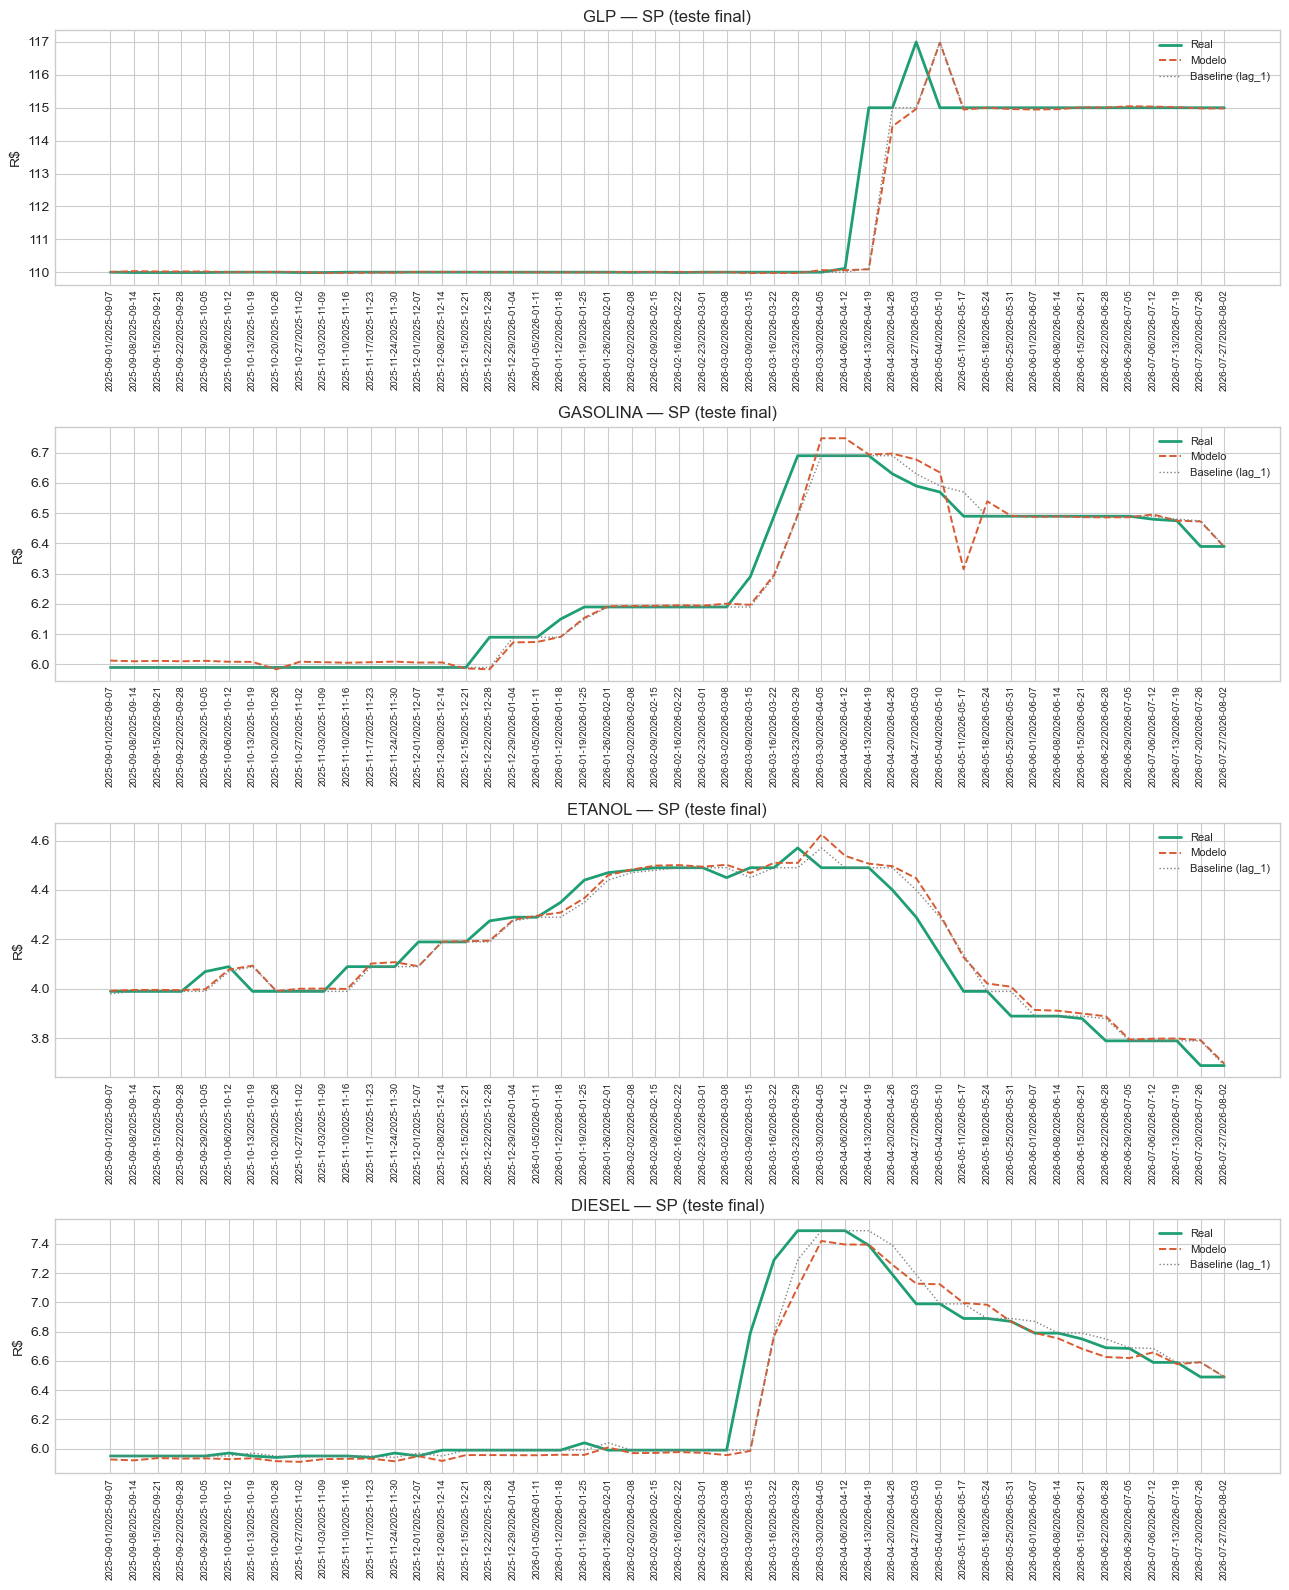

In [ ]:
def plot_previsao(df_resultado, produto, estado, ax=None):
    dados = df_resultado[
        (df_resultado['produto'] == produto) & (df_resultado['estado'] == estado)
    ].sort_values('dt_week')

    if ax is None:
        fig, ax = plt.subplots(figsize=(13, 4))

    ax.plot(dados['dt_week'].astype(str), dados['preco_real'],
            label='Real', color='#1D9E75', lw=2)
    ax.plot(dados['dt_week'].astype(str), dados['preco_previsto'],
            label='Modelo', color='#D85A30', lw=1.4, linestyle='--')
    ax.plot(dados['dt_week'].astype(str), dados['preco_baseline'],
            label='Baseline (lag_1)', color='gray', lw=1, linestyle=':')

    ax.set_title(f'{produto} — {estado} (teste final)')
    ax.set_ylabel('R$')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    return ax

# Exemplo — monte df_resultado_<produto> a partir de prever + reconstruir
# (mesma lógica usada durante a validação de cada produto)
fig, axes = plt.subplots(4, 1, figsize=(13, 16))
for ax, produto in zip(axes, ['GLP', 'GASOLINA', 'ETANOL', 'DIESEL']):
    plot_previsao(df_resultado_geral, produto, 'SP', ax=ax)
plt.tight_layout()
plt.show()


## 9. Conclusões e trabalhos futuros

- Pipeline completo e metodologicamente rigoroso: EDA fundamentada em testes
  de hipótese, engenharia de features validada estatisticamente (ACF/PACF,
  correlação defasada), baseline bem definido, validação temporal correta
  (`TimeSeriesSplit`), tuning bayesiano (Optuna) e confirmação cruzada entre
  dois algoritmos (XGBoost, LightGBM).
- Resultado principal: nenhum dos dois modelos supera de forma consistente
  um baseline de persistência no período de teste, devido a uma mudança de
  regime de mercado (salto de patamar do Brent/dólar) entre o fim do treino
  e o início do teste — uma limitação estrutural de extrapolação de modelos
  baseados em árvore de decisão.
- **Trabalhos futuros:** avaliar modelos com componente de tendência
  explícito (regressão linear regularizada, SARIMA, Prophet) ou abordagens
  híbridas (ensemble entre baseline e modelo de árvore), que podem lidar
  melhor com mudanças de patamar fora do range histórico.
